In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)



In [39]:
df=pd.read_csv(r"../data/processed/telco_customer_churn_cleaned.csv")

In [40]:
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LTV
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1936.30
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40


**1. TOTAL CUSTOMERS**

In [41]:
total_customers=df.shape[0]
print("Total customers=",total_customers)

Total customers= 7043


**2. CHURN COUNT AND CHURN RATE**

In [42]:
churn_count=df['Churn'].value_counts()
print("churned customer count =",churn_count)


churned customer count = Churn
No     5174
Yes    1869
Name: count, dtype: int64


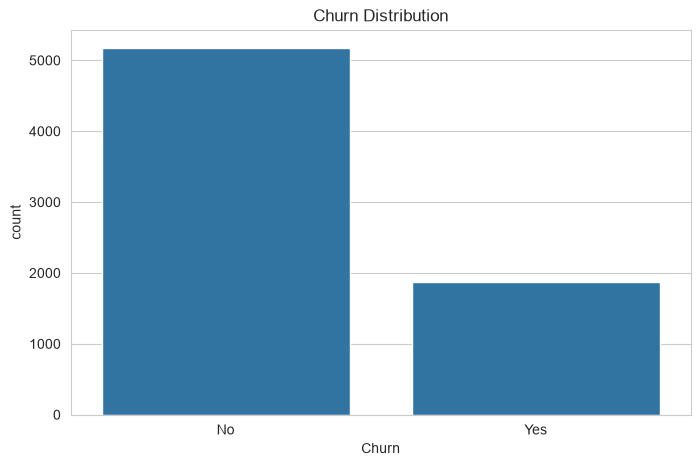

In [43]:
sns.countplot(x='Churn',data=df)
plt.title("Churn Distribution")
plt.show()

In [44]:
churn_rate = (df['Churn'].value_counts(normalize=True) * 100).round(2)
print(churn_rate)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


About 26.54% of customers have churned, while 73.46% remain active. This indicates that roughly **1 in 4 customers** leave the service.

**3. AVERAGE MONTHLY CHARGES BY CHURN**

In [45]:
avg_monthly = df.groupby('Churn')['MonthlyCharges'].mean().round(2)
print(avg_monthly)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


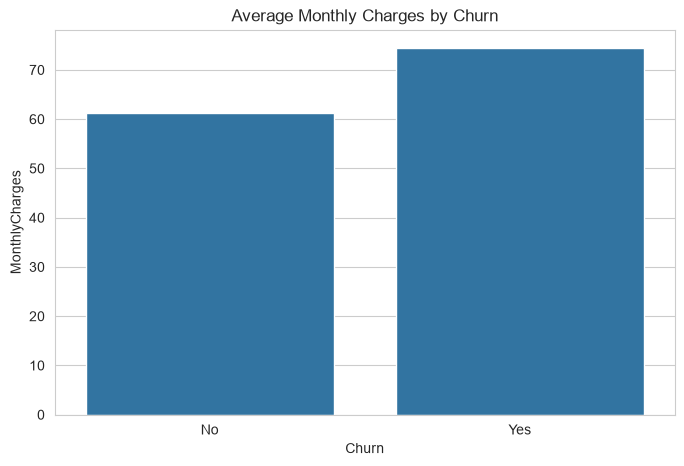

In [46]:
sns.barplot(x='Churn', y='MonthlyCharges', data=df,errorbar=None) 
plt.title('Average Monthly Charges by Churn') 
plt.show()

Customers who churn have higher average monthly charges than customers who stay

**4. CONTRACT TYPE DISTRIBUTION**

In [47]:
contract_counts = df['Contract'].value_counts() 
print(contract_counts)

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


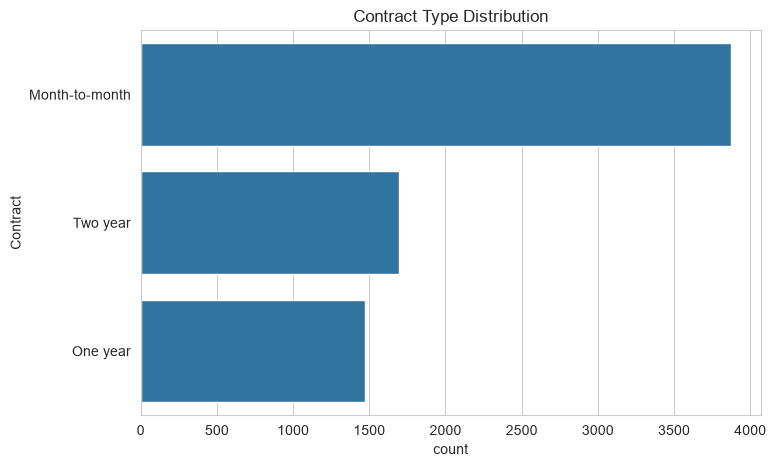

In [48]:
sns.countplot(y='Contract', data=df, order=df['Contract'].value_counts().index) 
plt.title('Contract Type Distribution') 
plt.show()

**Month-to-month contracts are the most common contract type** in the dataset, indicating that a large portion of customers have short-term commitments.

**5. AVERAGE TENURE BY CHURN**

In [49]:
df.groupby('Churn')['Tenure'].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: Tenure, dtype: float64

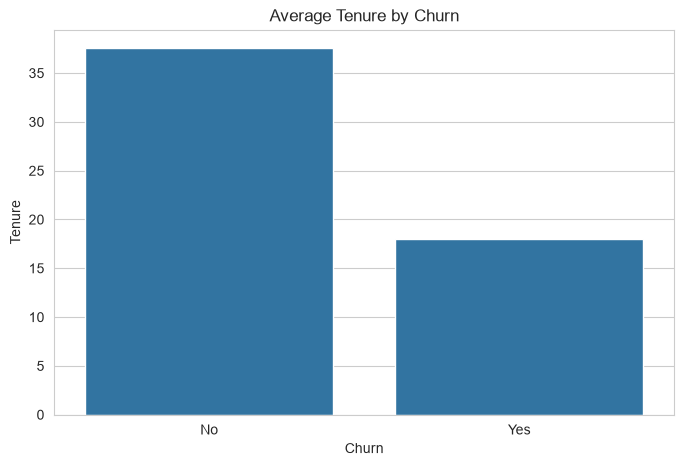

In [50]:
sns.barplot(x='Churn', y='Tenure', data=df,errorbar=None) 
plt.title('Average Tenure by Churn') 
plt.show()

In [51]:
tenure_summary = df.groupby('Churn')['Tenure'].agg(['count', 'mean', 'median']).round(2)
print(tenure_summary)

       count   mean  median
Churn                      
No      5174  37.57    38.0
Yes     1869  17.98    10.0


Customers who stay with the company have a much higher average tenure than customers who churn. This shows that **newer customers are more likely to leave**.

**6. CONTRACT TYPE  VS  CHURN**

In [52]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
print(contract_churn)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


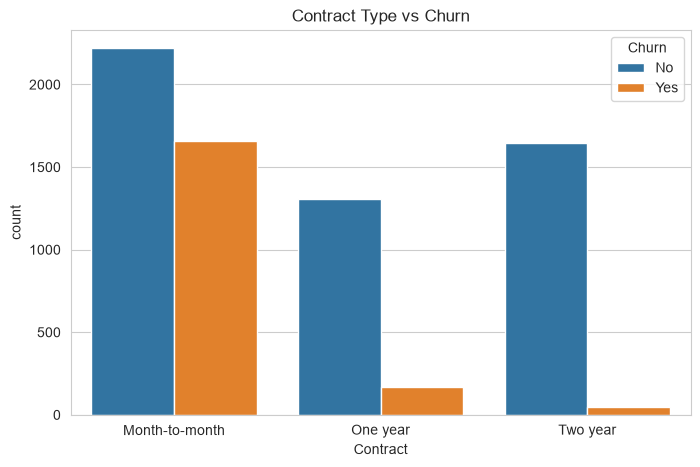

In [53]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.show()

**Month-to-month customers show the highest churn**, whereas one-year and especially two-year contracts have significantly lower churn.

**7. INTERNET SERVICE VS CHURN**

In [54]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'])
print(internet_churn)

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


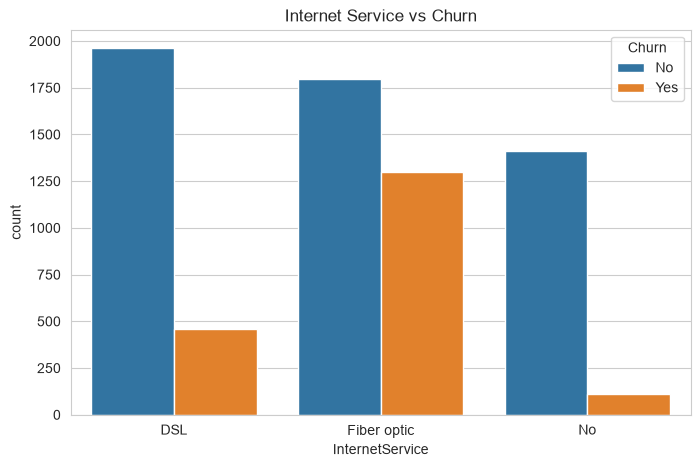

In [55]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Internet Service vs Churn')
plt.show()

Customers using **Fiber optic** internet service experience higher churn compared with DSL users.

**8. PAYMENT METHOD VS CHURN**

In [56]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'])
print(payment_churn)

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


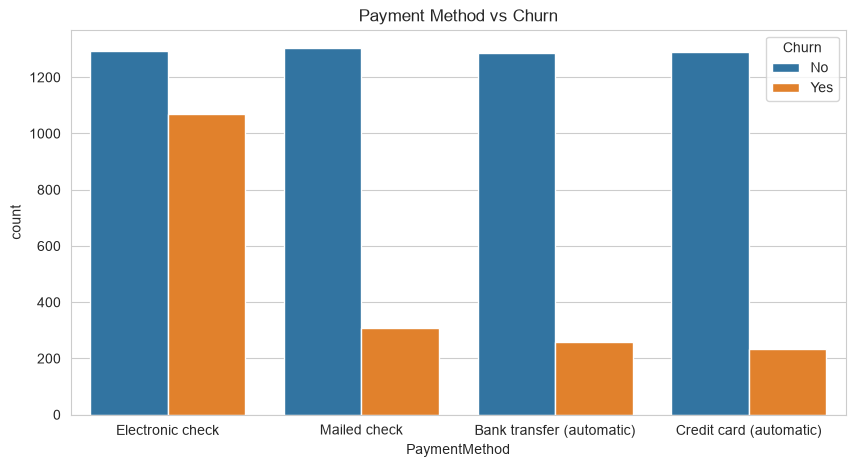

In [57]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Payment Method vs Churn')
plt.show()

Customers who use **Electronic Check** show the highest churn counts, while customers using automatic payment methods tend to have lower churn.

**9. TENURE GROUP VS CHURN**

In [58]:
# Create tenure group column
df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
    include_lowest=True
)

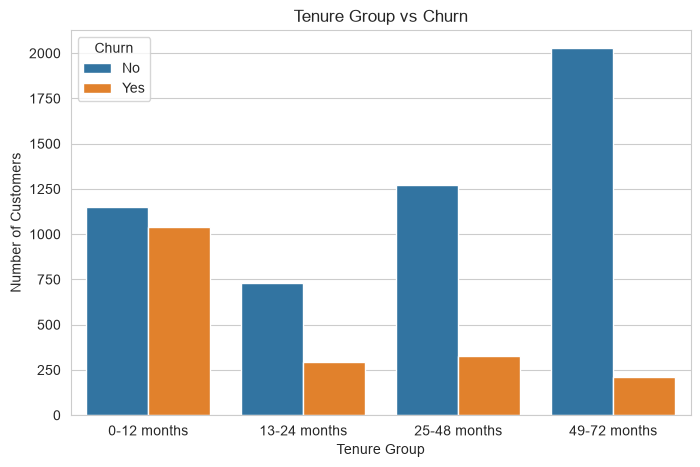

In [59]:
sns.countplot(data=df, x='TenureGroup', hue='Churn')
plt.title('Tenure Group vs Churn')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.show()

Customers in the 0–12 months tenure group show the highest churn count. Churn decreases as customer tenure increases, indicating that new customers are at the greatest risk of leaving, while long-term customers are more loyal.

**10. AVERAGE TENURE FOR EACH CONTRACT TYPE**

In [60]:
avg_tenure = df.groupby('Contract')['Tenure'].mean().round(2)
print(avg_tenure)

Contract
Month-to-month    18.04
One year          42.04
Two year          56.74
Name: Tenure, dtype: float64


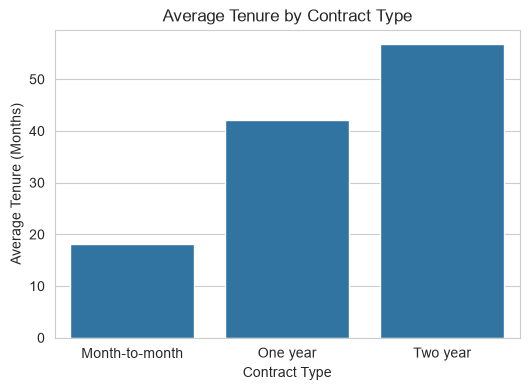

In [61]:
avg_tenure = df.groupby('Contract')['Tenure'].mean().sort_values()

plt.figure(figsize=(6,4))
sns.barplot(x=avg_tenure.index, y=avg_tenure.values)
plt.title('Average Tenure by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Average Tenure (Months)')
plt.show()

Customers who commit to **longer contracts** tend to **remain with the company for a much longer time** and are therefore **less likely to churn**.

**11. CORRELATION HEATMAP**

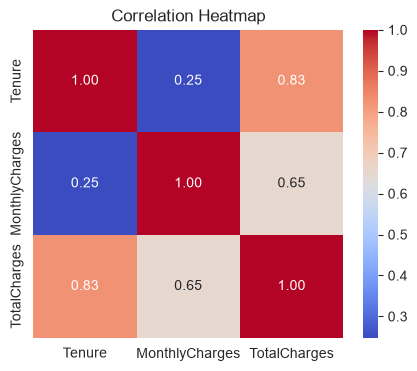

In [62]:
numeric_df = df[['Tenure', 'MonthlyCharges', 'TotalCharges']]

plt.figure(figsize=(5,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows that Tenure has a strong positive relationship with TotalCharges (0.83), indicating that customers who remain with the company for a longer period accumulate higher total charges. MonthlyCharges has a moderate positive relationship with TotalCharges (0.65), meaning customers with higher monthly fees tend to generate higher overall revenue. The relationship between Tenure and MonthlyCharges is weak (0.25), suggesting that the length of time a customer stays with the company does not strongly influence the monthly amount they pay.

## 12. KEY FINDINGS

* The overall **churn rate is 26.54%**.
* **Month-to-month contracts** have the highest churn.
* Customers with **short tenure (0–12 months)** are most likely to churn.
* **Higher monthly charges** are associated with increased churn.
* **Fiber optic customers** show relatively higher churn than DSL customers.
* Customers using **Electronic Check** have the highest churn counts.
* **Tenure has a strong positive relationship with TotalCharges (0.83)**, indicating that long-term customers generate higher revenue.
* Longer contract commitments are associated with **better customer retention and longer customer tenure**.
